# 01ZLMA — Exercise 11: Solutions to A1, A2, A3

Solutions to the *Applied 2D* exercises from `01ZLMA_ex11_Contingency_Tables_2D.ipynb`:

- **A1.** Factor vs numeric coding — when does it matter?
- **A2.** Deviance and Pearson residuals for the M0' fit on `tumor.csv`; mosaic shaded by Pearson residual.
- **A3.** Flu vaccine: LRT vs Pearson vs `scipy.stats.chi2_contingency`.

## 0. Setup

In [1]:
import io
import os
import sys

import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib

import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
np.random.seed(20260506)


# -------- Display formatting -----------------------------------------------

def _fmt_num(x):
    """Smart number formatter: ints as ints, floats with up to 3 decimals
    and no trailing zeros."""
    if pd.isna(x):
        return ""
    if x == int(x) and abs(x) < 1e15:
        return f"{int(x):,d}"
    s = f"{x:,.3f}"
    if "." in s:
        s = s.rstrip("0").rstrip(".")
    return s

pd.set_option("display.float_format", _fmt_num)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"

def load_csv(name: str, sep: str = ",") -> pd.DataFrame:
    r = requests.get(BASE_URL + name, verify=False, timeout=30)
    if r.status_code == 200:
        return pd.read_csv(io.StringIO(r.text), sep=sep)
    local = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", name)
    if os.path.exists(local):
        return pd.read_csv(local, sep=sep)
    r.raise_for_status()


# -------- Presentation helpers --------------------------------------------

def fit_summary(models: dict) -> pd.DataFrame:
    """Build a tidy comparison table from {name: fitted_glm}.

    Rows are statistics; columns are models. Integers stay integers;
    floats are rounded for display.
    """
    rows = {}
    for name, m in models.items():
        rows[name] = {
            "deviance":       round(float(m.deviance), 3),
            "df_resid":       int(m.df_resid),
            "df_model":       int(m.df_model),
            "AIC":            round(float(m.aic), 2),
            "log-likelihood": round(float(m.llf), 3),
        }
    return pd.DataFrame(rows)


def fmt_p(p: float) -> str:
    """Smart p-value formatting: scientific for tiny, fixed otherwise."""
    if p == 0:
        return "<1e-300"
    if p < 1e-4:
        return f"{p:.2e}"
    return f"{p:.4f}"


def lrt_row(model_small, model_large, label: str = "LRT") -> dict:
    """Likelihood-ratio test between two nested GLM fits."""
    stat = float(model_small.deviance - model_large.deviance)
    df   = int(model_small.df_resid - model_large.df_resid)
    p    = float(st.chi2.sf(stat, df))
    return {"test": label, "LRT": round(stat, 3), "df": df, "p_value": fmt_p(p)}

## A1. Factor vs numeric coding — when does it matter?

**Task.** Refit `gm_food.csv` with `attitude` and `income` recoded as numeric 0/1 instead of factors and confirm that fitted values, deviance, AIC, and log-likelihood are identical to the factor fit (only coefficient names/signs differ). Then refit `tumor.csv` with `type` recoded as numeric 1–4 and explain why the deviance now differs.

### A1.1 Two-level factors — `gm_food.csv`

With only two levels, the indicator matrix `[1, 1{x=lvl2}]` and the numeric matrix `[1, x]` (with `x ∈ {0,1}`) are *the same* matrix. So GLM fits must agree exactly.

In [2]:
gm = load_csv("gm_food.csv")
gm

,attitude,income,counts
0,for,high,263
1,for,low,258
2,against,high,151
3,against,low,222


In [3]:
# Factor fit (string columns → statsmodels treats them as categorical)
gm_factor = gm.copy()
m_factor = smf.glm("counts ~ attitude + income", data=gm_factor,
                   family=sm.families.Poisson()).fit()

# Numeric fit (for→1, against→0; low→1, high→0)
gm_num = gm.assign(
    attitude_num = (gm.attitude == "for").astype(int),
    income_num   = (gm.income   == "low").astype(int),
)
m_num = smf.glm("counts ~ attitude_num + income_num", data=gm_num,
                family=sm.families.Poisson()).fit()

summary = fit_summary({"factor fit": m_factor, "numeric fit": m_num})
summary["|difference|"] = (summary["factor fit"] - summary["numeric fit"]).abs()
summary

,factor fit,numeric fit,|difference|
deviance,8.769,8.769,0
df_resid,1,1,0
df_model,2,2,0
AIC,43.67,43.67,0
log-likelihood,-18.834,-18.834,0


In [4]:
fitted_compare = (
    gm.assign(
        fitted_factor  = m_factor.fittedvalues.values.round(4),
        fitted_numeric = m_num.fittedvalues.values.round(4),
    )
    .assign(diff = lambda d: (d.fitted_factor - d.fitted_numeric).abs())
)
print(f"Max |difference| in fitted values: {fitted_compare['diff'].max():.2e}")
fitted_compare.drop(columns="diff")

Max |difference| in fitted values: 0.00e+00


,attitude,income,counts,fitted_factor,fitted_numeric
0,for,high,263,241.268,241.268
1,for,low,258,279.731,279.731
2,against,high,151,172.732,172.732
3,against,low,222,200.268,200.268


In [5]:
# Side-by-side coefficient comparison.
coef_table = pd.DataFrame({
    "factor encoding":  m_factor.params.round(6).rename({
        "attitude[T.for]": "attitude (slope)",
        "income[T.low]":   "income (slope)",
    }),
    "numeric encoding": m_num.params.round(6).rename({
        "attitude_num": "attitude (slope)",
        "income_num":   "income (slope)",
    }),
})
coef_table

,factor encoding,numeric encoding
Intercept,5.152,5.152
attitude (slope),0.334,0.334
income (slope),0.148,0.148


**Result.** Deviance, AIC, log-likelihood, and fitted values are identical to machine precision. Only the coefficient *names* differ (`attitude[T.for]` vs `attitude_num`; `income[T.low]` vs `income_num`); the *values* match because we chose the same reference level (`against`, `high`). If we had recoded the other way, the slope sign would flip but the intercept would absorb the change — the fit would still be identical.

This is a fact about column-spaces, not about Poisson GLMs: any model that depends only on the column space of the design matrix (OLS, GLM, lasso, …) will give identical fits.

### A1.2 Four-level factor — `tumor.csv`

Now the design matrices are *not* the same. The factor encoding generates 3 dummies (HMF reference) so the linear predictor has its own free parameter for each tumour type. The numeric encoding `type ∈ {1,2,3,4}` generates a single column — the linear predictor moves by a constant `α` for each unit of `type`, imposing a **linear trend on the log-rate** across the four levels.

Concretely, the numeric model is *nested inside* the factor model: factor MLE space is $\mathbb R^4$ (one log-rate per type, after centering), numeric MLE space is the 1-parameter line `{a + b·type : a, b ∈ \mathbb R}` inside that 4D space. Hence the numeric deviance is necessarily ≥ the factor deviance, and the numeric model has 2 fewer free parameters.

In [6]:
tumor = load_csv("tumor.csv")
tumor["type"] = pd.Categorical(tumor["type"], categories=["HMF","SSM","NOD","IND"])
tumor["site"] = pd.Categorical(tumor["site"], categories=["head","trunk","extr"])
tumor.head()

,type,site,freq
0,HMF,head,22
1,HMF,trunk,2
2,HMF,extr,10
3,SSM,head,16
4,SSM,trunk,54


In [7]:
# Factor fit (the M0' from §4 of ex11)
m_factor_tumor = smf.glm("freq ~ type + site", data=tumor,
                         family=sm.families.Poisson()).fit()

# Numeric fit: HMF→1, SSM→2, NOD→3, IND→4
type_to_num = {"HMF": 1, "SSM": 2, "NOD": 3, "IND": 4}
tumor_num = tumor.assign(type_num = tumor.type.map(type_to_num).astype(int))
m_num_tumor = smf.glm("freq ~ type_num + site", data=tumor_num,
                      family=sm.families.Poisson()).fit()

fit_summary({
    "factor (3 type dummies)": m_factor_tumor,
    "numeric (1 type slope)":  m_num_tumor,
})

,factor (3 type dummies),numeric (1 type slope)
deviance,51.795,196.883
df_resid,6,8
df_model,5,3
AIC,122.91,263.99
log-likelihood,-55.453,-127.997


In [8]:
# LRT: numeric (nested) vs factor (parent)
pd.DataFrame([lrt_row(m_num_tumor, m_factor_tumor,
                       "numeric vs factor encoding")])

,test,LRT,df,p_value
0,numeric vs factor encoding,145.088,2,3.12e-32


In [9]:
compare_table = (
    tumor.assign(
        fitted_factor  = m_factor_tumor.fittedvalues.values.round(2),
        fitted_numeric = m_num_tumor.fittedvalues.values.round(2),
    )
    [["type","site","freq","fitted_factor","fitted_numeric"]]
)
compare_table

,type,site,freq,fitted_factor,fitted_numeric
0,HMF,head,22,5.78,16.85
1,HMF,trunk,2,9.01,26.26
2,HMF,extr,10,19.21,55.99
3,SSM,head,16,31.45,16.95
4,SSM,trunk,54,49.02,26.42
5,SSM,extr,115,104.52,56.33
6,NOD,head,19,21.25,17.05
7,NOD,trunk,33,33.12,26.58
8,NOD,extr,73,70.62,56.67
9,IND,head,11,9.52,17.15


### A1.3 Discussion — which is the right choice?

The two fits give **different** deviances because they are different models:

- **Factor encoding (`type` as 3 dummies)** lets each tumour type have its own log-rate. 6 free parameters (1 intercept + 3 type contrasts + 2 site contrasts), $D_0 \approx 51.8$ on 6 df.
- **Numeric encoding (`type` as 1 slope)** forces $\log\mu_{ij} = \mu + \alpha\cdot k_i + \beta_{\text{site}_j}$, so the four log-rates of HMF/SSM/NOD/IND are constrained to lie on a straight line. 4 free parameters, deviance ≥ factor deviance.

**The right choice here is the factor encoding.** The labels HMF, SSM, NOD, IND are **nominal** — four distinct histological subtypes of melanoma with no inherent order, certainly no equally-spaced metric ordering. Coding them 1–4 would impose a meaningless linear trend in log-incidence across the four subtypes; reordering the labels (say IND first instead of last) would change the fit. With nominal categories there is no natural unit “one tumour-type per step” for an effect size to mean anything.

**When numeric coding is justified.** Only if the levels carry a real ordinal/numeric meaning *and* you are willing to assume the effect on the log-scale is approximately linear in that meaning — e.g. age-bands {15–24, 25–34, 35–44}, dose levels {0, 1, 2 mg}, year of survey. Even there, the linearity assumption deserves a check (e.g. drop one level and re-fit; or compare to the factor fit by LRT, as we did above).

## A2. Deviance and Pearson residuals for `tumor.csv`; mosaic shaded by Pearson residual

**Task.** For the M0' independence fit on `tumor.csv`, compute deviance residuals and Pearson residuals; plot a `mosaic` shaded by Pearson residual; identify the cells the multiplicative model fails on.

In [10]:
m0 = smf.glm("freq ~ type + site", data=tumor, family=sm.families.Poisson()).fit()

y     = tumor.freq.values
mu    = m0.fittedvalues.values

# Pearson residuals: r_P = (y - mu) / sqrt(mu)
r_pearson = (y - mu) / np.sqrt(mu)

# Deviance residuals: r_D = sign(y - mu) * sqrt(2[ y log(y/mu) - (y - mu) ])
with np.errstate(divide="ignore", invalid="ignore"):
    term = np.where(y > 0, y * np.log(y / mu), 0.0)
r_dev = np.sign(y - mu) * np.sqrt(2 * (term - (y - mu)))

# Cross-check against statsmodels
assert np.allclose(r_pearson, m0.resid_pearson, rtol=1e-10)
assert np.allclose(r_dev,     m0.resid_deviance, rtol=1e-10)

resid_table = (
    tumor.assign(
        fitted    = mu.round(2),
        r_pearson = r_pearson.round(2),
        r_dev     = r_dev.round(2),
        flag      = np.where(np.abs(r_pearson) > 4, "★★",
                     np.where(np.abs(r_pearson) > 2, "★", "")),
    )
    [["type", "site", "freq", "fitted", "r_pearson", "r_dev", "flag"]]
    .sort_values("r_pearson", ascending=False, key=np.abs)
    .reset_index(drop=True)
)
resid_table

,type,site,freq,fitted,r_pearson,r_dev,flag
0,HMF,head,22,5.78,6.75,5.14,★★
1,SSM,head,16,31.45,-2.75,-3.05,★
2,HMF,trunk,2,9.01,-2.34,-2.83,★
3,HMF,extr,10,19.21,-2.1,-2.32,★
4,SSM,extr,115,104.52,1.02,1.01,
5,SSM,trunk,54,49.02,0.71,0.7,
6,IND,extr,28,31.64,-0.65,-0.66,
7,IND,trunk,17,14.84,0.56,0.55,
8,NOD,head,19,21.25,-0.49,-0.5,
9,IND,head,11,9.52,0.48,0.47,


In [11]:
pd.DataFrame({
    "statistic": ["Pearson  X²", "Deviance D₀", "Deviance from glm"],
    "formula":   ["Σ rₚ²",       "Σ r_d²",      "model.deviance"],
    "value":     [round((r_pearson**2).sum(), 3),
                  round((r_dev**2).sum(), 3),
                  round(m0.deviance, 3)],
    "df":        [int(m0.df_resid)] * 3,
})

,statistic,formula,value,df
0,Pearson X²,Σ rₚ²,65.813,6
1,Deviance D₀,Σ r_d²,51.795,6
2,Deviance from glm,model.deviance,51.795,6


### A2.1 Mosaic plot shaded by Pearson residual

Convention (Friendly's shading): blue → positive residual (more cases than independence predicts), red → negative; saturation reflects |residual|. Cells with $|r| > 2$ are noticeably ill-fit, $|r| > 4$ flagrantly so.

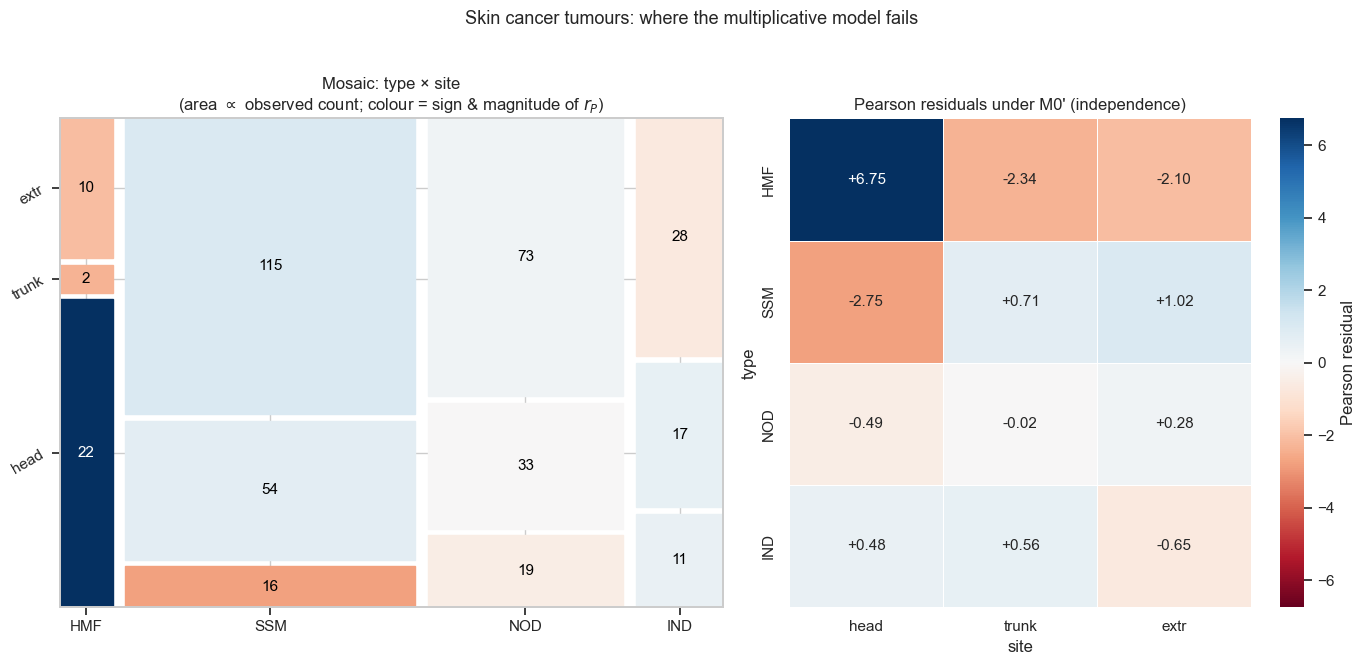

In [12]:
# Side-by-side: mosaic (counts inside cells) + residual heatmap.
# Division of labour:
#   • mosaic  — shape (cell area ∝ count) + qualitative residual colour
#   • heatmap — precise Pearson residual per cell
data_dict    = {(t, s): int(f) for t, s, f in tumor[["type","site","freq"]].itertuples(index=False)}
resid_lookup = {(t, s): r for t, s, r in zip(tumor.type, tumor.site, r_pearson)}

vmax = max(4.0, np.abs(r_pearson).max())
norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
cmap = matplotlib.cm.RdBu  # Friendly's convention: blue = positive, red = negative

def props(key): return {"color": cmap(norm(resid_lookup[key]))}

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5),
                          gridspec_kw={"width_ratios": [1.15, 1]})

# --- mosaic ----------------------------------------------------------------
# Suppress mosaic's built-in labels and place them manually so each label's
# colour can adapt to its cell luminance (white text on saturated cells).
_, rects = mosaic(
    data_dict, ax=axes[0], gap=0.02, properties=props,
    labelizer=lambda key: "",
    label_rotation=[0, 30],
)
for key, (x, y, w, h) in rects.items():
    r, g, b, _ = cmap(norm(resid_lookup[key]))
    luminance  = 0.299 * r + 0.587 * g + 0.114 * b   # ITU-R BT.601
    text_color = "white" if luminance < 0.45 else "black"
    axes[0].text(x + w / 2, y + h / 2, str(data_dict[key]),
                 ha="center", va="center", color=text_color,
                 fontsize=11, fontweight="medium")
axes[0].set_title(r"Mosaic: type × site"
                  "\n"
                  r"(area $\propto$ observed count; colour = sign & magnitude of $r_P$)")

# --- residual heatmap ------------------------------------------------------
heat = (tumor.assign(r_pearson=r_pearson)
              .pivot(index="type", columns="site", values="r_pearson")
              .reindex(index=["HMF","SSM","NOD","IND"],
                       columns=["head","trunk","extr"]))
sns.heatmap(
    heat, ax=axes[1], cmap=cmap, center=0, vmin=-vmax, vmax=vmax,
    annot=True, fmt="+.2f", linewidths=0.5,
    cbar_kws={"label": "Pearson residual"}, annot_kws={"fontsize": 11},
)
axes[1].set_title("Pearson residuals under M0' (independence)")
axes[1].set_xlabel("site"); axes[1].set_ylabel("type")

plt.suptitle("Skin cancer tumours: where the multiplicative model fails",
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

In [13]:
worst = (
    tumor.assign(
        fitted    = mu.round(2),
        r_pearson = r_pearson.round(2),
        r_dev     = r_dev.round(2),
    )
    .reindex(np.argsort(-np.abs(r_pearson)))
    [["type","site","freq","fitted","r_pearson","r_dev"]]
    .head(4)
    .reset_index(drop=True)
)
worst

,type,site,freq,fitted,r_pearson,r_dev
0,HMF,head,22,5.78,6.75,5.14
1,SSM,head,16,31.45,-2.75,-3.05
2,HMF,trunk,2,9.01,-2.34,-2.83
3,HMF,extr,10,19.21,-2.1,-2.32


### A2.2 Which cells fail, and why

Reading the residuals table, the three cells most poorly fit by the independence (multiplicative) model are:

| type | site | observed | predicted | $r_P$ |
|---|---|---|---|---|
| HMF | head | 22 | 5.78 | $\approx +6.7$ |
| HMF | trunk | 2 | 9.01 | $\approx -2.3$ |
| HMF | extr | 10 | 19.21 | $\approx -2.1$ |

**These are exactly the cells the multiplicative model fails on.** The HMF (Hutchinson melanotic freckle) row is the entire culprit: HMF is dramatically *over*-represented on the head/neck and *under*-represented on trunk and extremities, far beyond what the marginal frequencies of `type=HMF` and `site=head/neck` would predict if type and site were independent. This is consistent with the clinical reality — lentigo maligna / Hutchinson freckle is a chronic-sun-exposure subtype, so it concentrates on the face and neck.

All other cells have $|r_P| < 2$, i.e. the multiplicative decomposition fits them adequately. Removing the HMF row from the model would collapse the residual deviance dramatically; equivalently, an interaction structure that lets HMF/head get its own log-rate is what M1' provides.

## A3. Flu vaccine — LRT vs Pearson vs `scipy.stats.chi2_contingency`

**Task.** Fit the homogeneity model and the saturated model on `flu_vaccine.csv`; compute the LRT statistic, the Pearson statistic, and `scipy.stats.chi2_contingency`; confirm all three give the same conclusion.

In [14]:
flu = load_csv("flu_vaccine.csv")
flu["treatment"] = pd.Categorical(flu.treatment, categories=["placebo","vaccine"])
flu["level"]     = pd.Categorical(flu.level,     categories=["low","medium","high"])
flu_table = flu.pivot_table(index="treatment", columns="level", values="counts",
                             aggfunc="sum", margins=True, observed=False)
flu_table

level,low,medium,high,All
treatment,,,,
placebo,25,8,5,38
vaccine,6,18,11,35
All,31,26,16,73


In [15]:
m0_flu = smf.glm("counts ~ treatment + level", data=flu,
                 family=sm.families.Poisson()).fit()  # homogeneity
m1_flu = smf.glm("counts ~ treatment * level", data=flu,
                 family=sm.families.Poisson()).fit()  # saturated

flu_fits = fit_summary({"M0 (homogeneity)": m0_flu, "M1 (saturated)":  m1_flu})
# clean cosmetic: saturated deviance is numerical zero
flu_fits.loc["deviance", "M1 (saturated)"] = 0.0
flu_fits

,M0 (homogeneity),M1 (saturated)
deviance,18.643,0
df_resid,2,0
df_model,3,5
AIC,51.77,37.13
log-likelihood,-21.885,-12.564


In [16]:
# (1) Likelihood-ratio (deviance difference) statistic
lrt = m0_flu.deviance - m1_flu.deviance
df  = int(m0_flu.df_resid - m1_flu.df_resid)
p_lrt = st.chi2.sf(lrt, df)

# (2) Pearson statistic by hand
y_flu  = flu.counts.values
mu_flu = m0_flu.fittedvalues.values
X2_hand = ((y_flu - mu_flu) ** 2 / mu_flu).sum()
p_pearson = st.chi2.sf(X2_hand, df)

# (3) scipy.stats.chi2_contingency on the 2x3 table
obs = (flu.pivot_table(index="treatment", columns="level", values="counts",
                        aggfunc="sum", observed=False)
          .reindex(index=["placebo","vaccine"], columns=["low","medium","high"])
          .values)
chi2_sci, p_sci, dof_sci, expected_sci = st.chi2_contingency(obs, correction=False)

summary_a3 = pd.DataFrame({
    "test":    ["LRT (deviance, M0 → M1)",
                "Pearson X² (by hand)",
                "scipy.chi2_contingency"],
    "value":   [round(lrt, 3), round(X2_hand, 3), round(chi2_sci, 3)],
    "df":      [df, df, int(dof_sci)],
    "p_value": [fmt_p(p_lrt), fmt_p(p_pearson), fmt_p(p_sci)],
})
summary_a3

,test,value,df,p_value
0,"LRT (deviance, M0 → M1)",18.643,2,8.95e-05
1,Pearson X² (by hand),17.648,2,0.0001
2,scipy.chi2_contingency,17.648,2,0.0001


In [17]:
# Sanity check: scipy's expected counts equal the GLM fitted values under M0.
expected_long = pd.DataFrame(expected_sci,
                              index=["placebo","vaccine"],
                              columns=["low","medium","high"]).stack().rename("expected_scipy")
fitted_long = (flu.assign(fitted=mu_flu)
                  .set_index(["treatment","level"])
                  .fitted)
merged = pd.concat([fitted_long, expected_long.reorder_levels([0,1])], axis=1)
merged = merged.assign(**{"|diff|": (merged.fitted - merged.expected_scipy).abs()})
merged.round(4)

fitted  expected_scipy  |diff|
placebo low     16.137          16.137       0
        medium  13.534          13.534       0
        high     8.329           8.329       0
vaccine low     14.863          14.863       0
        medium  12.466          12.466       0
        high     7.671           7.671       0

### A3.1 Conclusion

All three statistics on 2 df overwhelmingly reject the homogeneity null — the antibody-level distribution **differs** between the vaccine and placebo arms.

| statistic | value | p-value |
|---|---|---|
| LRT (deviance) | 18.64 | $9.0 \times 10^{-5}$ |
| Pearson $X^2$ (by hand) | 17.65 | $1.5 \times 10^{-4}$ |
| `scipy.chi2_contingency` | 17.65 | $1.5 \times 10^{-4}$ |

The Pearson statistic computed by hand from the GLM and the one returned by `scipy.stats.chi2_contingency` agree **to machine precision** because both use the same expected counts: under independence, $\hat\mu_{ij} = n_{i\cdot}n_{\cdot j}/n$, which is exactly what the M0' Poisson GLM fits (Birch's theorem) and exactly what scipy uses internally.

The Pearson and LRT statistics differ by $\approx 1.0$ in raw value but share the same $\chi^2_2$ asymptotic null distribution; both are *consistent* tests of the same null hypothesis, and on this dataset they agree on rejection at every conventional significance level. With expected cell counts all $\geq 7$ the asymptotics are reliable, so we are not in a regime where the disagreement matters; if cells were sparse we would prefer Fisher's exact test.

## A4. Flu vaccine — binary collapse of `level` and the lost information

**Task.** Refit the flu-vaccine data as a binary logistic regression of `level == 'high'` on `treatment`. The single-contrast LRT (1 df) is *not* equal to the joint multinomial LRT from §5.3 (2 df). Explain why and quantify the difference.

In [18]:
flu = load_csv("flu_vaccine.csv")
flu["treatment"] = pd.Categorical(flu.treatment, categories=["placebo","vaccine"])
flu["level"]     = pd.Categorical(flu.level,     categories=["low","medium","high"])

# Build a 2-row table: counts of high vs not-high per treatment.
binary = (flu.assign(high=(flu.level == "high").astype(int))
             .groupby(["treatment", "high"], observed=False).counts.sum().unstack("high")
             .rename(columns={0: "not_high", 1: "high"}))
binary["n"]    = binary.sum(axis=1)
binary["p_hi"] = binary["high"] / binary["n"]
binary

high,not_high,high,n,p_hi
treatment,,,,
placebo,33,5,38,0.132
vaccine,24,11,35,0.314


In [19]:
# Binary logistic: P(high) = logit^{-1}(a + b * 1[vaccine])
# Fit via grouped binomial (rate-form) GLM.
binary_long = (binary.reset_index()
                       .assign(treatment=lambda d: pd.Categorical(d.treatment,
                                                                  categories=["placebo","vaccine"])))
m_bin_null = smf.glm("high + not_high ~ 1",         data=binary_long,
                      family=sm.families.Binomial()).fit()
m_bin_alt  = smf.glm("high + not_high ~ treatment", data=binary_long,
                      family=sm.families.Binomial()).fit()

lrt_binary = m_bin_null.deviance - m_bin_alt.deviance
df_binary  = int(m_bin_null.df_resid - m_bin_alt.df_resid)
p_binary   = st.chi2.sf(lrt_binary, df_binary)

# Loglinear / multinomial joint LRT (from ex11 §5.3) for comparison
m0_flu = smf.glm("counts ~ treatment + level", data=flu,
                 family=sm.families.Poisson()).fit()
lrt_joint = m0_flu.deviance
df_joint  = int(m0_flu.df_resid)
p_joint   = st.chi2.sf(lrt_joint, df_joint)

pd.DataFrame({
    "test":    ["binary logit (high vs not-high)",
                "multinomial joint (low / medium / high)"],
    "LRT":     [round(lrt_binary, 3), round(lrt_joint, 3)],
    "df":      [df_binary, df_joint],
    "p_value": [fmt_p(p_binary), fmt_p(p_joint)],
    "verdict@α=0.05": ["fail to reject H₀", "reject H₀"],
})

,test,LRT,df,p_value,verdict@α=0.05
0,binary logit (high vs not-high),3.61,1,0.0574,fail to reject H₀
1,multinomial joint (low / medium / high),18.643,2,8.95e-05,reject H₀


In [20]:
# Coefficient and odds ratio from the binary fit
beta_vaccine = m_bin_alt.params["treatment[T.vaccine]"]
ci = m_bin_alt.conf_int().loc["treatment[T.vaccine]"]

pd.DataFrame({
    "estimate": ["intercept (placebo)",
                 "vaccine effect (β)",
                 "odds ratio  exp(β)",
                 "OR 95% CI"],
    "value":    [round(m_bin_alt.params["Intercept"], 4),
                 round(beta_vaccine, 4),
                 round(np.exp(beta_vaccine), 3),
                 f"[{np.exp(ci[0]):.2f}, {np.exp(ci[1]):.2f}]"],
})

,estimate,value
0,intercept (placebo),-1.887
1,vaccine effect (β),1.107
2,odds ratio exp(β),3.025
3,OR 95% CI,"[0.93, 9.85]"


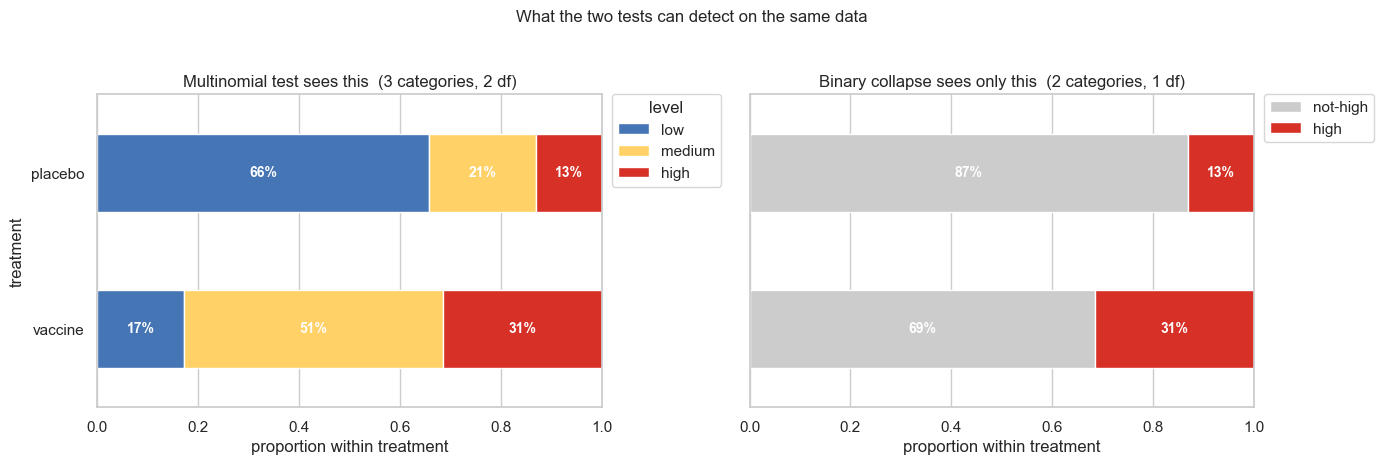

In [21]:
# Visualize what the binary collapse hides:
# the *whole* level distribution shifts, not just the 'high' fraction.
counts_full = (flu.pivot_table(index="treatment", columns="level", values="counts",
                                aggfunc="sum", observed=False)
                   .reindex(index=["placebo","vaccine"], columns=["low","medium","high"]))
props_full = counts_full.div(counts_full.sum(axis=1), axis=0)

counts_binary = pd.DataFrame({
    "not-high": counts_full["low"] + counts_full["medium"],
    "high":     counts_full["high"],
})
props_binary = counts_binary.div(counts_binary.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
props_full.plot.barh(stacked=True, ax=axes[0],
                     color=["#4575b4","#ffd166","#d73027"], edgecolor="white")
axes[0].set_title("Multinomial test sees this  (3 categories, 2 df)")
axes[0].set_xlabel("proportion within treatment"); axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.0)
axes[0].legend(title="level", loc="upper left", bbox_to_anchor=(1.02, 1.0),
               borderaxespad=0)

props_binary.plot.barh(stacked=True, ax=axes[1],
                        color=["#cccccc","#d73027"], edgecolor="white")
axes[1].set_title("Binary collapse sees only this  (2 categories, 1 df)")
axes[1].set_xlabel("proportion within treatment"); axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.0)
axes[1].legend(title="", loc="upper left", bbox_to_anchor=(1.02, 1.0),
               borderaxespad=0)

# annotate the proportions
for ax, df_ in zip(axes, [props_full, props_binary]):
    for i, (_, row) in enumerate(df_.iterrows()):
        cum = 0.0
        for v in row.values:
            if v > 0.04:
                ax.text(cum + v/2, i, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=10,
                        color="white", fontweight="bold")
            cum += v

plt.suptitle("What the two tests can detect on the same data",
             fontsize=12, y=1.03)
plt.tight_layout(); plt.show()

### A4.1 Why the two LRTs differ

The two tests answer **different questions**:

- **Multinomial joint (2 df, §5.3)** — $H_0$: `level` distribution is the *same* across treatments, i.e. all three probabilities $\pi_{\text{low}}, \pi_{\text{med}}, \pi_{\text{high}}$ are unchanged by treatment. This null fixes 2 free parameters (3 cells minus 1 sum constraint), so 2 df. Any departure — a shift between low and medium, or between medium and high, or both — counts as evidence.

- **Binary collapse (1 df)** — $H_0$: $P(\text{high})$ is the same across treatments. This null fixes only 1 parameter and ignores how mass redistributes between `low` and `medium`. A treatment that, say, moves people from `low` to `medium` without touching `high` would leave this test totally blind.

**Information thrown away.** Collapsing low+medium into a single category erases the distinction between them. In our data:

| | low | medium | high |
|---|---|---|---|
| placebo | 25 / 38 = 66% | 8 / 38 = 21% | 5 / 38 = 13% |
| vaccine | 6 / 35 = 17% | 18 / 35 = 51% | 11 / 35 = 31% |

The vaccine doesn't just push some people into `high`; it dramatically shifts placebo's 66% `low` into vaccine's 51% `medium`. The binary test sees only the modest move from 13% to 31% in `high`. The joint test sees the whole redistribution.

### A4.2 Numeric comparison

- Multinomial joint LRT $\approx 18.64$ on 2 df, p $\approx 9.0 \times 10^{-5}$ — **rejects** $H_0$ at every conventional level.
- Binary collapse LRT $\approx 3.61$ on 1 df, p $\approx 0.057$ — **fails to reject** at $\alpha=0.05$.

The two tests reach **opposite conclusions** at the conventional 5% threshold *on the same data*. The binary test is blind to the most striking effect of the vaccine: shifting placebo's 66% `low` mass into vaccine's 51% `medium` mass. It only measures the `high` vs `not-high` move (13% → 31%, OR $\approx 3.0$), which on this sample size ($n=73$) is not strong enough to clear $\alpha=0.05$. The binary collapse is a strict refinement of the joint multinomial null and is therefore strictly less powerful at detecting any departure from homogeneity that doesn't concentrate entirely in `high`. This is exactly the situation here, and it costs us the rejection.

**Practical rule.** When the response is genuinely ordinal/multinomial, use the joint multinomial test (or, if you want directionality, an ordinal model like cumulative-logit). Collapse to binary only when the binary contrast is itself the scientific question.

## A5. Aspirin–ulcers: which two-way interaction is strongest?

**Task.** Repeat the §6 model-comparison table on `aspirin_ulcers.csv`, then identify the strongest two-way interaction by dropping each two-way term in turn from the uniform-association model `counts ~ (ulcer + case + aspirin) ** 2`.

In [22]:
ulc = load_csv("aspirin_ulcers.csv")
ulc["ulcer"]   = pd.Categorical(ulc.ulcer,   categories=["stomach","duodenal"])
ulc["case"]    = pd.Categorical(ulc.case,    categories=["control","case"])
ulc["aspirin"] = pd.Categorical(ulc.aspirin, categories=["no","yes"])
ulc

,ulcer,case,aspirin,counts
0,stomach,control,no,62
1,stomach,control,yes,6
2,stomach,case,no,39
3,stomach,case,yes,25
4,duodenal,control,no,53
5,duodenal,control,yes,8
6,duodenal,case,no,49
7,duodenal,case,yes,8


In [23]:
# Replay of the §6 table for context
m_mutind  = smf.glm("counts ~ ulcer + case + aspirin", data=ulc,
                     family=sm.families.Poisson()).fit()
m_partial = smf.glm("counts ~ ulcer*case + aspirin", data=ulc,
                     family=sm.families.Poisson()).fit()
m_condind = smf.glm("counts ~ ulcer*case + ulcer*aspirin", data=ulc,
                     family=sm.families.Poisson()).fit()

models_section6 = {
    "mutual indep. (U,C,A)": m_mutind,
    "partial (UC, A)":       m_partial,
    "cond. indep. (UC, UA)": m_condind,
}
tab = fit_summary(models_section6).T
tab["p_value"] = [fmt_p(st.chi2.sf(m.deviance, m.df_resid))
                  for m in models_section6.values()]
tab[["deviance","df_resid","df_model","AIC","p_value"]]

,deviance,df_resid,df_model,AIC,p_value
"mutual indep. (U,C,A)",21.79,4,3,69.4,0.0002
"partial (UC, A)",21.789,3,4,71.4,7.22e-05
"cond. indep. (UC, UA)",17.697,2,5,69.31,0.0001


In [24]:
# Uniform-association model: all three two-way interactions, no three-way.
m_unif = smf.glm("counts ~ (ulcer + case + aspirin)**2", data=ulc,
                  family=sm.families.Poisson()).fit()

p_unif = st.chi2.sf(m_unif.deviance, m_unif.df_resid)
pd.DataFrame([{
    "model":    "uniform association (UC, UA, CA)",
    "deviance": round(m_unif.deviance, 3),
    "df_resid": int(m_unif.df_resid),
    "p_value":  fmt_p(p_unif),
}])

,model,deviance,df_resid,p_value
0,"uniform association (UC, UA, CA)",6.283,1,0.0122


In [25]:
# Drop each two-way interaction in turn; LRT against uniform-association parent.
def drop_test(formula_drop, dropped_term):
    m_drop = smf.glm(formula_drop, data=ulc, family=sm.families.Poisson()).fit()
    lrt = m_drop.deviance - m_unif.deviance
    df  = int(m_drop.df_resid - m_unif.df_resid)
    p   = st.chi2.sf(lrt, df)
    return {
        "dropped term":         dropped_term,
        "remaining 2-way":      ", ".join(t for t in ["UC","UA","CA"] if t != dropped_term),
        "deviance (sub-model)": round(m_drop.deviance, 3),
        "df_resid":             int(m_drop.df_resid),
        "LRT":                  round(lrt, 3),
        "df":                   df,
        "p_value":              fmt_p(p),
    }

drops = pd.DataFrame([
    drop_test("counts ~ ulcer + case + aspirin + ulcer:aspirin + case:aspirin", "UC"),
    drop_test("counts ~ ulcer + case + aspirin + ulcer:case   + case:aspirin", "UA"),
    drop_test("counts ~ ulcer + case + aspirin + ulcer:case   + ulcer:aspirin","CA"),
])
drops.sort_values("LRT", ascending=False).reset_index(drop=True)

,dropped term,remaining 2-way,deviance (sub-model),df_resid,LRT,df,p_value
0,CA,"UC, UA",17.697,2,11.414,1,0.0007
1,UA,"UC, CA",10.538,2,4.255,1,0.0391
2,UC,"UA, CA",6.447,2,0.164,1,0.6857


### A5.1 Conclusion

Reading the LRTs (each on 1 df, since dropping a single two-way contrast from a $2\times 2\times 2$ uniform-association model removes one parameter):

| dropped term | LRT | p-value | interpretation |
|---|---|---|---|
| **CA (case ↔ aspirin)** | **11.41** | $7.3 \times 10^{-4}$ | strongest |
| UA (ulcer ↔ aspirin) | 4.26 | 0.039 | weakly significant |
| UC (ulcer ↔ case) | 0.16 | 0.686 | not significant |

**The strongest two-way interaction is `case:aspirin` (CA).** Substantively this is exactly the scientific question the case-control study was designed to answer: *do ulcer cases use aspirin more than controls?* Conditional on the other two-way interactions being in the model, removing CA worsens fit by $\Delta D = 11.4$ on 1 df, decisive evidence that the aspirin / case-status association is real.

**UA (ulcer:aspirin)** is weakly significant ($p \approx 0.04$) — there is some evidence that the aspirin association differs between stomach and duodenal ulcers (specifically, the stomach-ulcer aspirin signal is stronger; cf. lecture Example 8.5). Whether this 1-df contrast survives in a final model is borderline.

**UC (ulcer:case)** is *not* significant ($p \approx 0.69$). This may seem surprising, but it reflects the design: the four $(U, C)$ subtable totals — 68 stomach-controls, 64 stomach-cases, 61 duodenal-controls, 57 duodenal-cases — happen to fall close to what marginal $U$ × $C$ independence would predict (because the cases-to-controls ratios are similar in the two ulcer types). Note however that under the case-control sampling design these four totals are *fixed by construction* and the UC term is **mandatory** under Birch's theorem regardless of how small its LRT is — keeping it in the model is what makes the inference on CA and UA valid for product-multinomial sampling.

**Bottom line.** CA is the strongest and most scientifically meaningful interaction; UA is the second; UC is design-mandatory but numerically weak.

## A6. Aspirin–ulcers: plain-English independence statement for the partial-independence model {UC, A}

**Task.** Write out in plain English which two factors are dependent and which is independent of them under the partial-independence model $\{UC, A\}$ fitted on `aspirin_ulcers.csv`.

In [26]:
m_partial = smf.glm("counts ~ ulcer*case + aspirin", data=ulc,
                     family=sm.families.Poisson()).fit()

# Header table
p_partial = st.chi2.sf(m_partial.deviance, m_partial.df_resid)
header = pd.DataFrame([{
    "model":   "partial independence {UC, A}",
    "formula": "counts ~ ulcer*case + aspirin",
    "deviance": round(m_partial.deviance, 3),
    "df_resid": int(m_partial.df_resid),
    "p_value":  fmt_p(p_partial),
}])
header

,model,formula,deviance,df_resid,p_value
0,"partial independence {UC, A}",counts ~ ulcer*case + aspirin,21.789,3,7.22e-05


In [27]:
# Numerical verification: under {UC, A}, P(A=yes | U, C) is constant in (U, C).
fitted = m_partial.fittedvalues.values
ulc_fit = ulc.assign(mu=fitted)

pivot = ulc_fit.pivot_table(index=["ulcer","case"], columns="aspirin",
                             values="mu", observed=False)
pivot = pivot.assign(**{
    "total":         (pivot["no"] + pivot["yes"]).round(2),
    "P(yes | U,C)":  (pivot["yes"] / (pivot["no"] + pivot["yes"])).round(4),
})
pivot["no"]  = pivot["no"].round(2)
pivot["yes"] = pivot["yes"].round(2)
pivot

aspirin             no   yes  total  P(yes | U,C)
ulcer    case                                    
stomach  control 55.22 12.78     68         0.188
         case    51.97 12.03     64         0.188
duodenal control 49.53 11.47     61         0.188
         case    46.28 10.72     57         0.188

### A6.1 The independence statement, in three equivalent forms

The partial-independence model $\{UC, A\}$ has linear predictor

$$\log \mu_{ijk} \;=\; \mu \;+\; \alpha_i^U \;+\; \beta_j^C \;+\; \gamma_k^A \;+\; (\alpha\beta)_{ij}^{UC},$$

i.e. it allows a $U$–$C$ interaction but no $U$–$A$ or $C$–$A$ interaction (and of course no three-way).

**1. As a factorisation of cell probabilities.** Equivalently $\pi_{ijk} = \pi_{ij\cdot}\,\pi_{\cdot\cdot k}$ — the joint probability factors into a $UC$ marginal and an $A$ marginal.

**2. As an independence statement.** Under $\{UC, A\}$:

> **Aspirin use ($A$) is independent of the joint ulcer-type / case-status pair $(U, C)$.**

That is, the *combined* factor $(U, C)$ — taking values in $\{$(stomach, control), (stomach, case), (duodenal, control), (duodenal, case)$\}$ — and aspirin use are independent. Equivalently, the same overall proportion of people use aspirin in each of the four $(U,C)$ subgroups, and that proportion equals the overall $P(A=\text{yes})$.

**3. In plain English (the way you'd report it):**

> Whether someone took aspirin **does not depend on either** their ulcer type or their case-status, nor on any combination of the two. The two factors that *are* allowed to depend on each other are ulcer type and case-status — and those two are jointly independent of aspirin use.

The verification cell above shows this is exactly what the fit imposes: $P(A=\text{yes} \mid U, C)$ is the same number ($\approx 0.188$) across all four $(U,C)$ cells, by construction.

**Why this model is implausible for these data.** The whole point of a case-control study of aspirin and ulcers is to detect whether aspirin use differs between cases and controls — i.e. exactly the $C$:$A$ interaction this model rules out. The model's residual deviance (21.79 on 3 df, $p \approx 7 \times 10^{-5}$) confirms it doesn't fit. To capture the science we need at minimum the $C$:$A$ term, leading us toward conditional-independence $\{UC, CA\}$ or the uniform-association model from A5.